In [1]:
import common_functions

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import numpy as np
import rioxarray as rxr
import xarray as xr
from pyproj import CRS, Transformer
import os
import rasterio

In [2]:
dust_points_vars = pd.read_csv("DATA/processed/3_dust_points_vars_2026-04-24.csv")
location_name = "American Southwest"

In [3]:
def add_squares_to_plot(ax, color="white"):

    regions = {
        "Region 1": [(31.75, -108.00), (31.00, -107.25)],  # 369 events
        "Region 2": [(31.05, -107.20), (30.30, -106.45)],  # 205 events
        "Region 3": [(40.25, -118.70), (39.50, -117.95)],  # 161 events
        "Region 4": [(41.00, -119.75), (40.25, -119.00)],  # 140 events
        "Region 5": [(33.30, -102.65), (32.55, -101.90)],  # 139 events
        "Region 6": [(30.80, -108.00), (30.05, -107.25)],  # 112 events
        "Region 7": [(31.80, -107.25), (31.05, -106.50)],  # 94 events
        "Region 8": [(31.60, -108.75), (30.85, -108.00)],  # 86 events
        "Region 9": [(34.15, -103.10), (33.40, -102.35)],  # 79 events
        "Region 10": [(35.85, -111.25), (35.10, -110.50)],  # 76 events
        "Region 11": [(29.50, -107.00), (28.75, -106.25)],  # 76 events
        "Region 12": [(33.00, -106.90), (32.25, -106.15)],  # 61 events
        "Region 13": [(32.55, -102.25), (31.80, -101.50)],  # 58 events
        "Region 14": [(37.00, -110.25), (36.25, -109.50)],  # 57 events
        "Region 15": [(36.45, -108.95), (35.70, -108.20)],  # 55 events
        "Region 16": [(38.15, -106.30), (37.40, -105.55)],  # 55 events
        "Region 17": [(33.40, -103.40), (32.65, -102.65)],  # 54 events
        "Region 18": [(32.55, -108.05), (31.80, -107.30)],  # 53 events
        "Region 19": [(38.15, -118.15), (37.40, -117.40)],  # 49 events
        "Region 20": [(39.15, -113.35), (38.40, -112.60)],  # 37 events
        "Region 21": [(32.45, -110.10), (31.70, -109.35)],  # 36 events
        "Region 22": [(29.85, -107.95), (29.10, -107.20)],  # 35 events
        "Region 23": [(28.75, -107.15), (28.00, -106.40)],  # 34 events
        "Region 24": [(42.00, -117.30), (41.25, -116.55)],  # 32 events
        "Region 25": [(34.70, -103.85), (33.95, -103.10)],  # 31 events
        "Region 26": [(31.25, -105.15), (30.50, -104.40)],  # 29 events
        "Region 27": [(38.55, -104.65), (37.80, -103.90)],  # 29 events
        "Region 28": [(38.60, -103.40), (37.85, -102.65)],  # 29 events
        "Region 29": [(33.30, -101.90), (32.55, -101.15)],  # 29 events
        "Region 30": [(41.45, -119.00), (40.70, -118.25)],  # 27 events
        "Region 31": [(30.80, -106.45), (30.05, -105.70)],  # 26 events
        "Region 32": [(29.30, -105.10), (28.55, -104.35)],  # 26 events
        "Region 33": [(35.55, -116.80), (34.80, -116.05)],  # 25 events
        "Region 34": [(34.05, -102.35), (33.30, -101.60)],  # 25 events
        "Region 35": [(29.65, -106.25), (28.90, -105.50)],  # 24 events
        "Region 36": [(32.55, -115.70), (31.80, -114.95)],  # 23 events
        "Region 37": [(36.60, -111.70), (35.85, -110.95)],  # 23 events
        "Region 38": [(27.20, -104.30), (26.45, -103.55)],  # 22 events
        "Region 39": [(31.45, -103.85), (30.70, -103.10)],  # 22 events
        "Region 40": [(32.55, -103.00), (31.80, -102.25)],  # 21 events
        "Region 41": [(40.70, -120.50), (39.95, -119.75)],  # 19 events
        "Region 42": [(35.30, -110.50), (34.55, -109.75)],  # 19 events
        "Region 43": [(34.50, -116.00), (33.75, -115.25)],  # 18 events
        "Region 44": [(33.25, -116.45), (32.50, -115.70)],  # 17 events
    }

    for name, ((lat1, lon1), (lat2, lon2)) in regions.items():

        min_lat = min(lat1, lat2)
        max_lat = max(lat1, lat2)
        min_lon = min(lon1, lon2)
        max_lon = max(lon1, lon2)
        
        width = max_lon - min_lon
        height = max_lat - min_lat
        
        rect = patches.Rectangle(
            (min_lon, min_lat),
            width,
            height,
            linewidth=3,
            edgecolor=color,
            facecolor='none',
            zorder=9,
            transform=ccrs.PlateCarree()
        )
        
        ax.add_patch(rect)

    return

In [4]:
def plot_dust_point_contour_map(dust_df, location_name):
    
    fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={"projection": ccrs.PlateCarree()},)

    #--- Plot dust points
    ax.scatter(
        dust_df["longitude"],
        dust_df["latitude"],
        transform=ccrs.PlateCarree(),
        s=12,
        marker="o",
        facecolors='#e7cd24',
        edgecolors='#e7cd24',
        linewidth=1, 
        alpha=0.5,
        zorder=6
    )

    add_squares_to_plot(ax)

    ax.set_title("Blowing dust origin points with contours (2001-2020)", fontsize=24, pad=12)

    all_states_provinces = cfeature.NaturalEarthFeature(category='cultural',
        name='admin_1_states_provinces', scale='10m', facecolor='none')
    ax.add_feature(all_states_provinces, edgecolor='white', linewidth=2, zorder=2)
    ax.add_feature(cfeature.BORDERS, edgecolor='white', linewidth=2, zorder=2)
    ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=3)
    ax.add_feature(cfeature.LAND, facecolor='black', zorder=1)

    min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    plt.tight_layout()
    plt.show()
    return

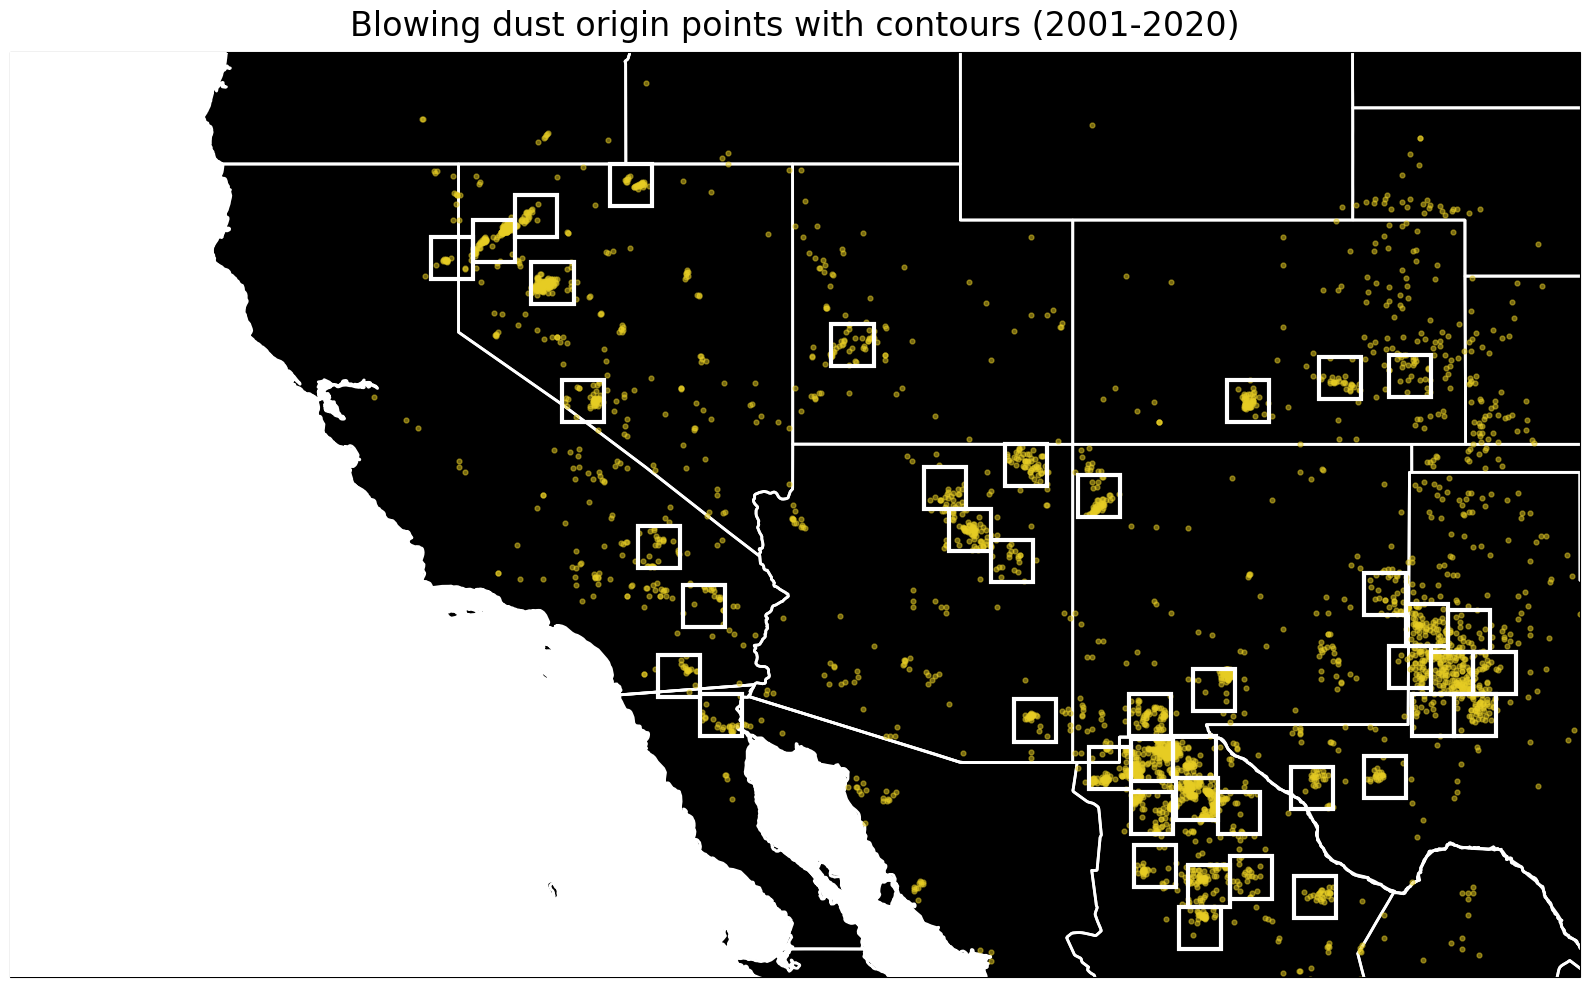

In [5]:
plot_dust_point_contour_map(dust_points_vars, location_name)

In [6]:
def plot_gldas_soil_texture_map(texture_ds, location_name):

    soil_cmap, texture_colors, texture_dict = common_functions.get_texture_map_features()

    fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={"projection": ccrs.PlateCarree()})

    texture_da = texture_ds.GLDAS_soiltex

    texture_da.plot(
        ax=ax,
        cmap=soil_cmap,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    add_squares_to_plot(ax)


    all_states_provinces = cfeature.NaturalEarthFeature(category='cultural',
        name='admin_1_states_provinces', scale='10m', facecolor='none')
    ax.add_feature(all_states_provinces, edgecolor="black", linewidth=0.8)
    ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.8)
    min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    
    ax.set_title("Soil Textures with Dust Origins", fontsize=24, pad=12)
    legend_handles = [
        Patch(facecolor=color, edgecolor="black", label=label)
        for label, color in zip(texture_dict.values(), texture_colors)
    ]

    dust_handle = Patch(
        facecolor="white",
        edgecolor="black",
        label="Dust Origin"
    )
    ax.legend(
        handles=legend_handles + [dust_handle],
        title="Soil Texture",
        loc="lower left",
        frameon=True
    )

    plt.show()
    return

In [7]:
def open_gldas_file(gldas_path):
    ds = xr.open_dataset(gldas_path)
    return ds

In [8]:
def filter_to_region(ds, location_name):

    lat_min, lat_max, lon_min, lon_max = common_functions._get_coords_for_region(location_name)

    filtered_ds = ds.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max)
    )
    return filtered_ds

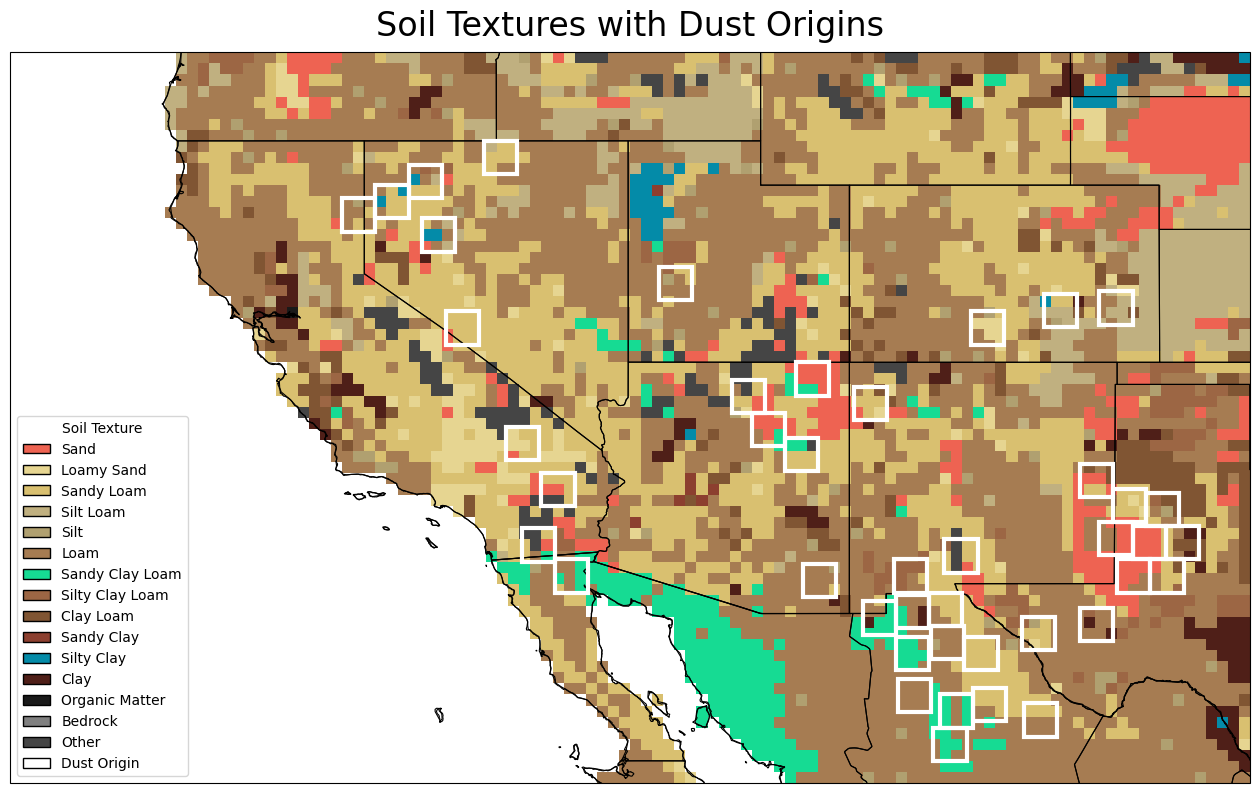

In [9]:
gldas_path = "DATA/raw/gldas_soil_texture/GLDASp5_soiltexture_025d.nc4"
texture_ds = open_gldas_file(gldas_path)
texture_ds = filter_to_region(texture_ds, location_name)

plot_gldas_soil_texture_map(texture_ds, location_name)

In [10]:
soil_order_dict, category_colors = common_functions.get_soil_order_features()

In [11]:
def get_soil_order_indices(soil_da):
    #--- Get colormap associated with soil order names
    #------ Colormaps not synced up due to spatial plot not following

    unique_orders = list(dict.fromkeys(soil_order_dict.values()))
    order_to_index = {order: i for i, order in enumerate(unique_orders)}
    colors = [category_colors[o] for o in unique_orders]
    cmap = mcolors.ListedColormap(colors)
    n_categories = len(unique_orders)
    norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, n_categories+0.5, 1), ncolors=n_categories)

    default_order = "No data"
    flat_values = soil_da.values.ravel()
    flat_indices = np.array([
        order_to_index.get(soil_order_dict.get(int(code), default_order), order_to_index[default_order])
        for code in flat_values
    ])
    soil_indices = soil_da.copy()
    soil_indices.values = flat_indices.reshape(soil_da.shape)

    return unique_orders, cmap, norm, colors, soil_indices

In [12]:
def plot_usda_soil_types_map(soil_da, location_name):

    unique_orders, cmap, norm, colors, soil_indices = get_soil_order_indices(soil_da)

    fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={"projection": ccrs.PlateCarree()})

    soil_indices.plot(
        ax=ax,
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    add_squares_to_plot(ax)

    all_states_provinces = cfeature.NaturalEarthFeature(category='cultural',
        name='admin_1_states_provinces', scale='10m', facecolor='none')
    ax.add_feature(all_states_provinces, edgecolor="black", linewidth=0.8)
    ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.8)
    min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    
    ax.set_title("USDA Soil Orders with Dust Origins", fontsize=24, pad=12)

    unique_indices = np.unique(soil_indices.values)
    legend_elements = [
        Patch(facecolor=colors[i], label=name)
        for i, name in enumerate(unique_orders)
        if i in unique_indices
    ]

    ax.legend(
        handles=legend_elements,
        title="Soil Type",
        loc="lower left",
        frameon=True
    )

    plt.show()
    return

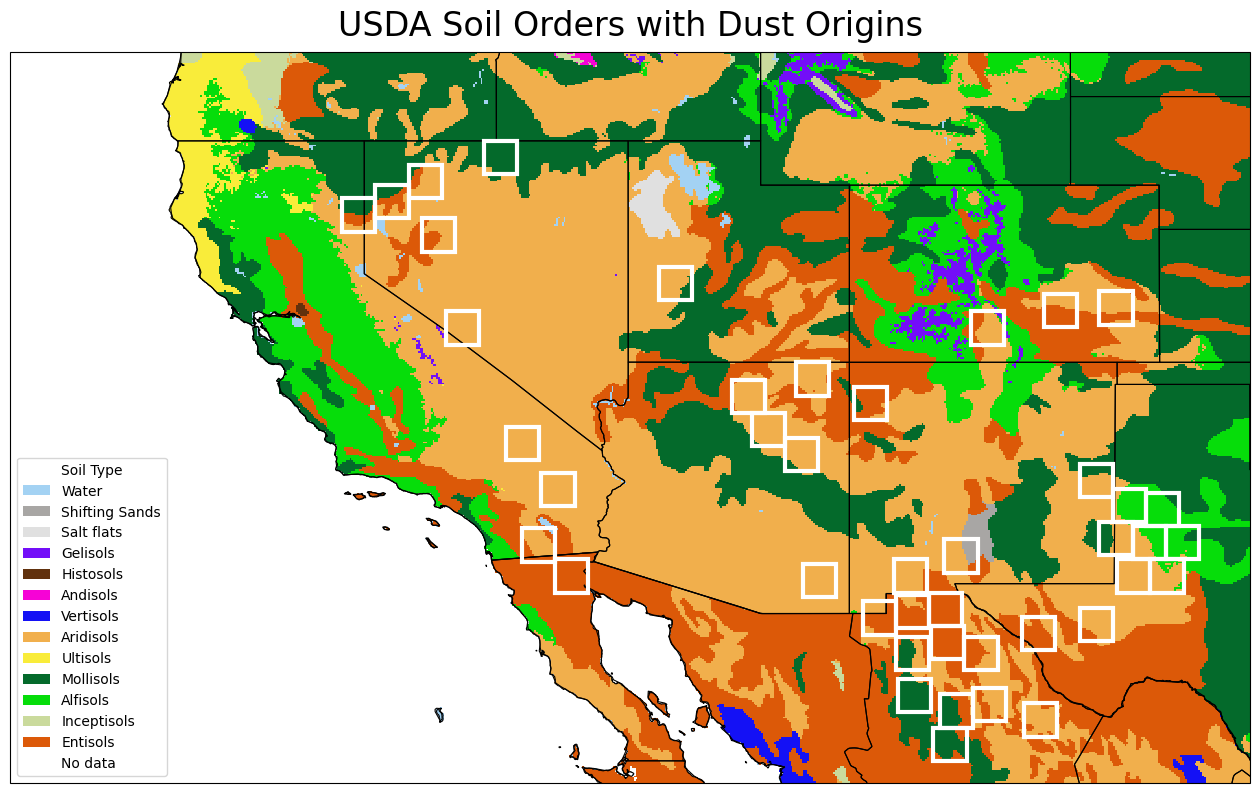

In [13]:
usda_filepath = "DATA/raw/soil_types_usda/global-soil-suborders-2022.tif"
min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)

soil_da = (
    rxr.open_rasterio(usda_filepath)
    .squeeze("band", drop=True)
    .rio.clip_box(
        minx=min_lon,
        miny=min_lat,
        maxx=max_lon,
        maxy=max_lat,
    )
)

plot_usda_soil_types_map(soil_da, location_name)

In [14]:
def get_cec_land_cover_reprojection(cec_full, location_name):
    min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
    min_lat_extend = min_lat - 5
    max_lat_extend = max_lat + 4

    src_crs = CRS.from_epsg(4326) 
    dst_crs = CRS.from_wkt(cec_full.rio.crs.to_wkt()) 
    transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True) 
    minx, miny = transformer.transform(min_lon, min_lat_extend) 
    maxx, maxy = transformer.transform(max_lon, max_lat_extend) 
    minx, maxx = sorted([minx, maxx]) 
    miny, maxy = sorted([miny, maxy]) 
    cec_cropped = cec_full.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)

    output_path = "DATA/processed/cec_land_cover/cec_land_cover_SW_epsg4326.tif"
    if not os.path.exists(output_path):
        print("Reprojecting to lat/lon...") 
        cec = cec_cropped.rio.reproject( 
            "EPSG:4326", 
            resolution=0.05, 
            resampling=rasterio.enums.Resampling.nearest)
        cec.rio.to_raster(output_path)
    else:
        print("Processed raster already exists — skipping reprojection.")
        cec = rxr.open_rasterio(output_path).squeeze("band", drop=True)

    return cec

In [15]:
def plot_land_cover_map(cec_ds, location_name):

    land_cover_dict, land_cover_colors, classes = common_functions.get_land_cover_features()

    codes = np.array(sorted(classes))
    names = [classes[c][0] for c in codes]
    colors = [classes[c][1] for c in codes]

    cmap = mcolors.ListedColormap(colors)
    cec_ds = cec_ds.where(np.isin(cec_ds, codes)) #--- Null values are not included
    norm = mcolors.BoundaryNorm(
        boundaries=np.append(codes - 0.5, codes[-1] + 0.5),
        ncolors=len(colors),
    )

    fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={"projection": ccrs.PlateCarree()},)

    cec_ds.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
    )

    add_squares_to_plot(ax)

    ax.set_title("Land Cover Categories with Dust Origins", fontsize=24, pad=12)

    all_states_provinces = cfeature.NaturalEarthFeature(category='cultural',
        name='admin_1_states_provinces', scale='10m', facecolor='none')
    ax.add_feature(all_states_provinces, linewidth=0.8)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=3)
    min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    legend_handles = [
        Patch(color=color, label=name)
        for name, color in zip(names, colors)
    ]

    ax.legend(
        handles=legend_handles,
        title="Land Cover Class",
        loc="lower left",
        frameon=True
    )
    
    plt.tight_layout()
    plt.show()

    return

Processed raster already exists — skipping reprojection.


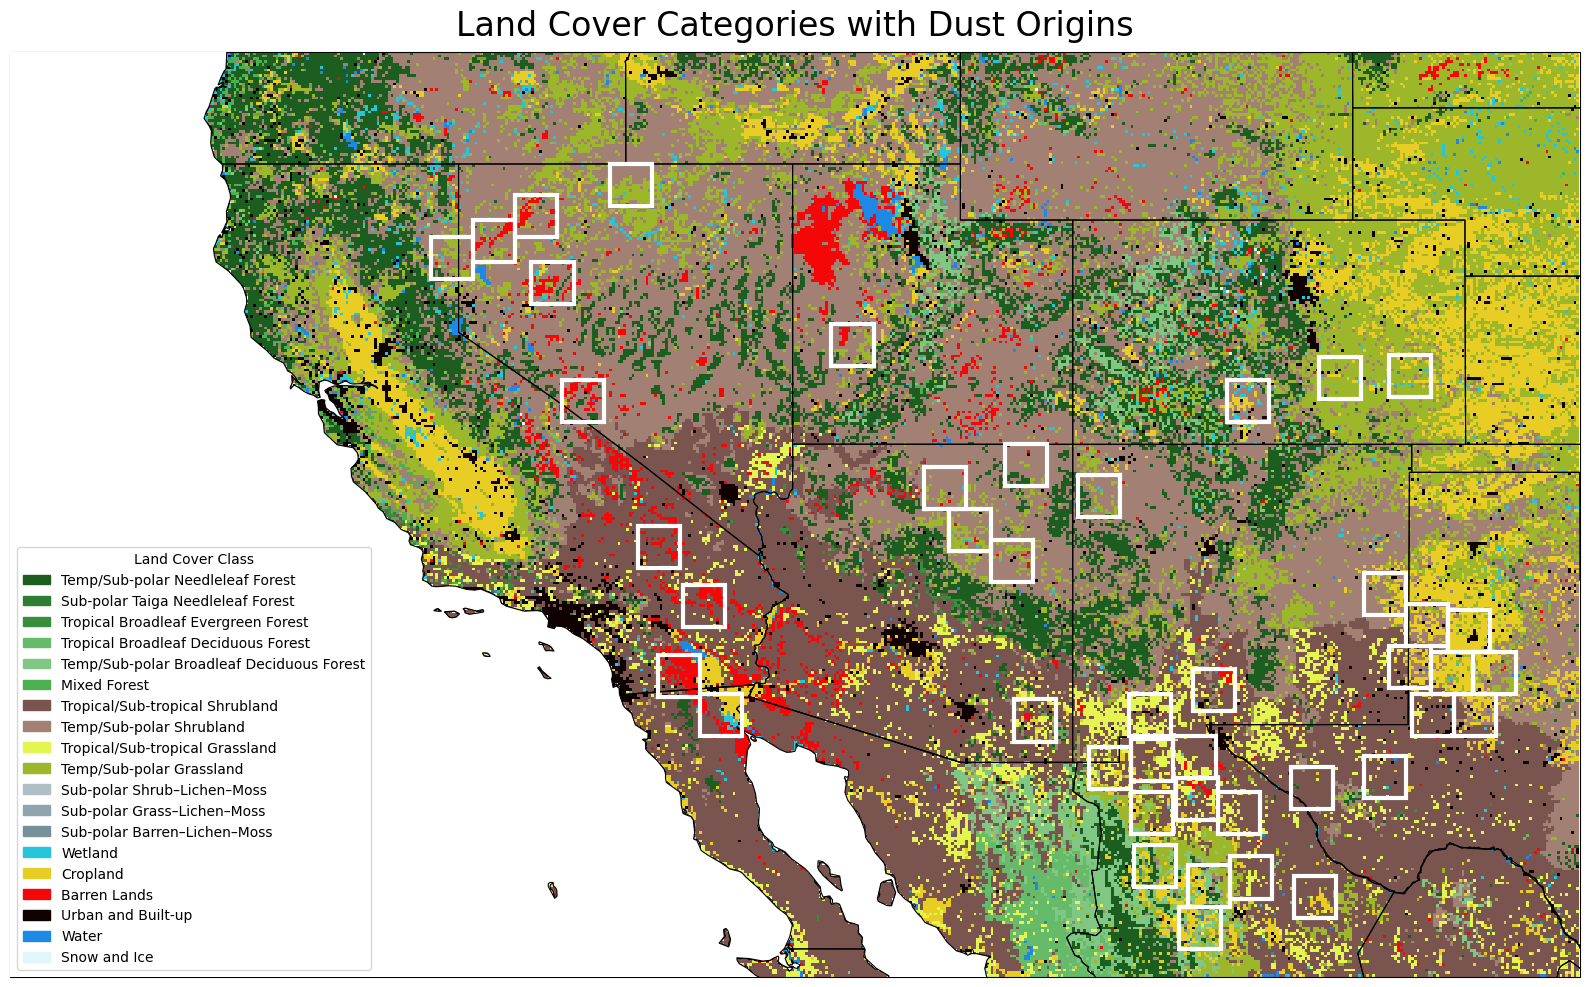

In [16]:
cec_filepath = ("DATA/raw/cec_land_cover/NA_NALCMS_landcover_2020v2_30m/data/NA_NALCMS_landcover_2020v2_30m.tif")
cec_full = rxr.open_rasterio(cec_filepath).squeeze("band", drop=True)
cec_ds = get_cec_land_cover_reprojection(cec_full, location_name)

plot_land_cover_map(cec_ds, location_name)

## Wind days over 10 m/s

A few thoughts on this. 
* The dust boxes idea is pretty clunky, doesn't get the message across
* The dust points and wind speeds are on two different grids, but the wind speed grid is curvilinear
* For this reason, it would require some thinking to get a wind grid of dust probability

In [18]:
wind_ds = xr.open_dataset("DATA/processed/2_wind_grid_2026-04-23.nc")


winds_over_10 = (wind_ds['wind_speed'] > 10).sum(dim='time')
total_num_wind_days = len(wind_ds['time'])


In [29]:
from scipy.spatial import cKDTree

points = np.column_stack((wind_ds.lat.values.ravel(), wind_ds.lon.values.ravel()))

tree = cKDTree(points)

query_points = np.column_stack((dust_points_vars['latitude'], dust_points_vars['longitude']))
dist, idx = tree.query(query_points)

i, j = np.unravel_index(idx, wind_ds.lat.shape)

In [33]:
counts = np.zeros_like(wind_ds.lat, dtype=int)

for ii, jj in zip(i, j):
    counts[ii, jj] += 1

/home/jturner/miniconda3/envs/wldas_env/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: divide by zero encountered in divide
  result_data = func(*input_data)
/home/jturner/miniconda3/envs/wldas_env/lib/python3.12/site-packages/xarray/core/computation.py:821: RuntimeWarning: invalid value encountered in divide
  result_data = func(*input_data)


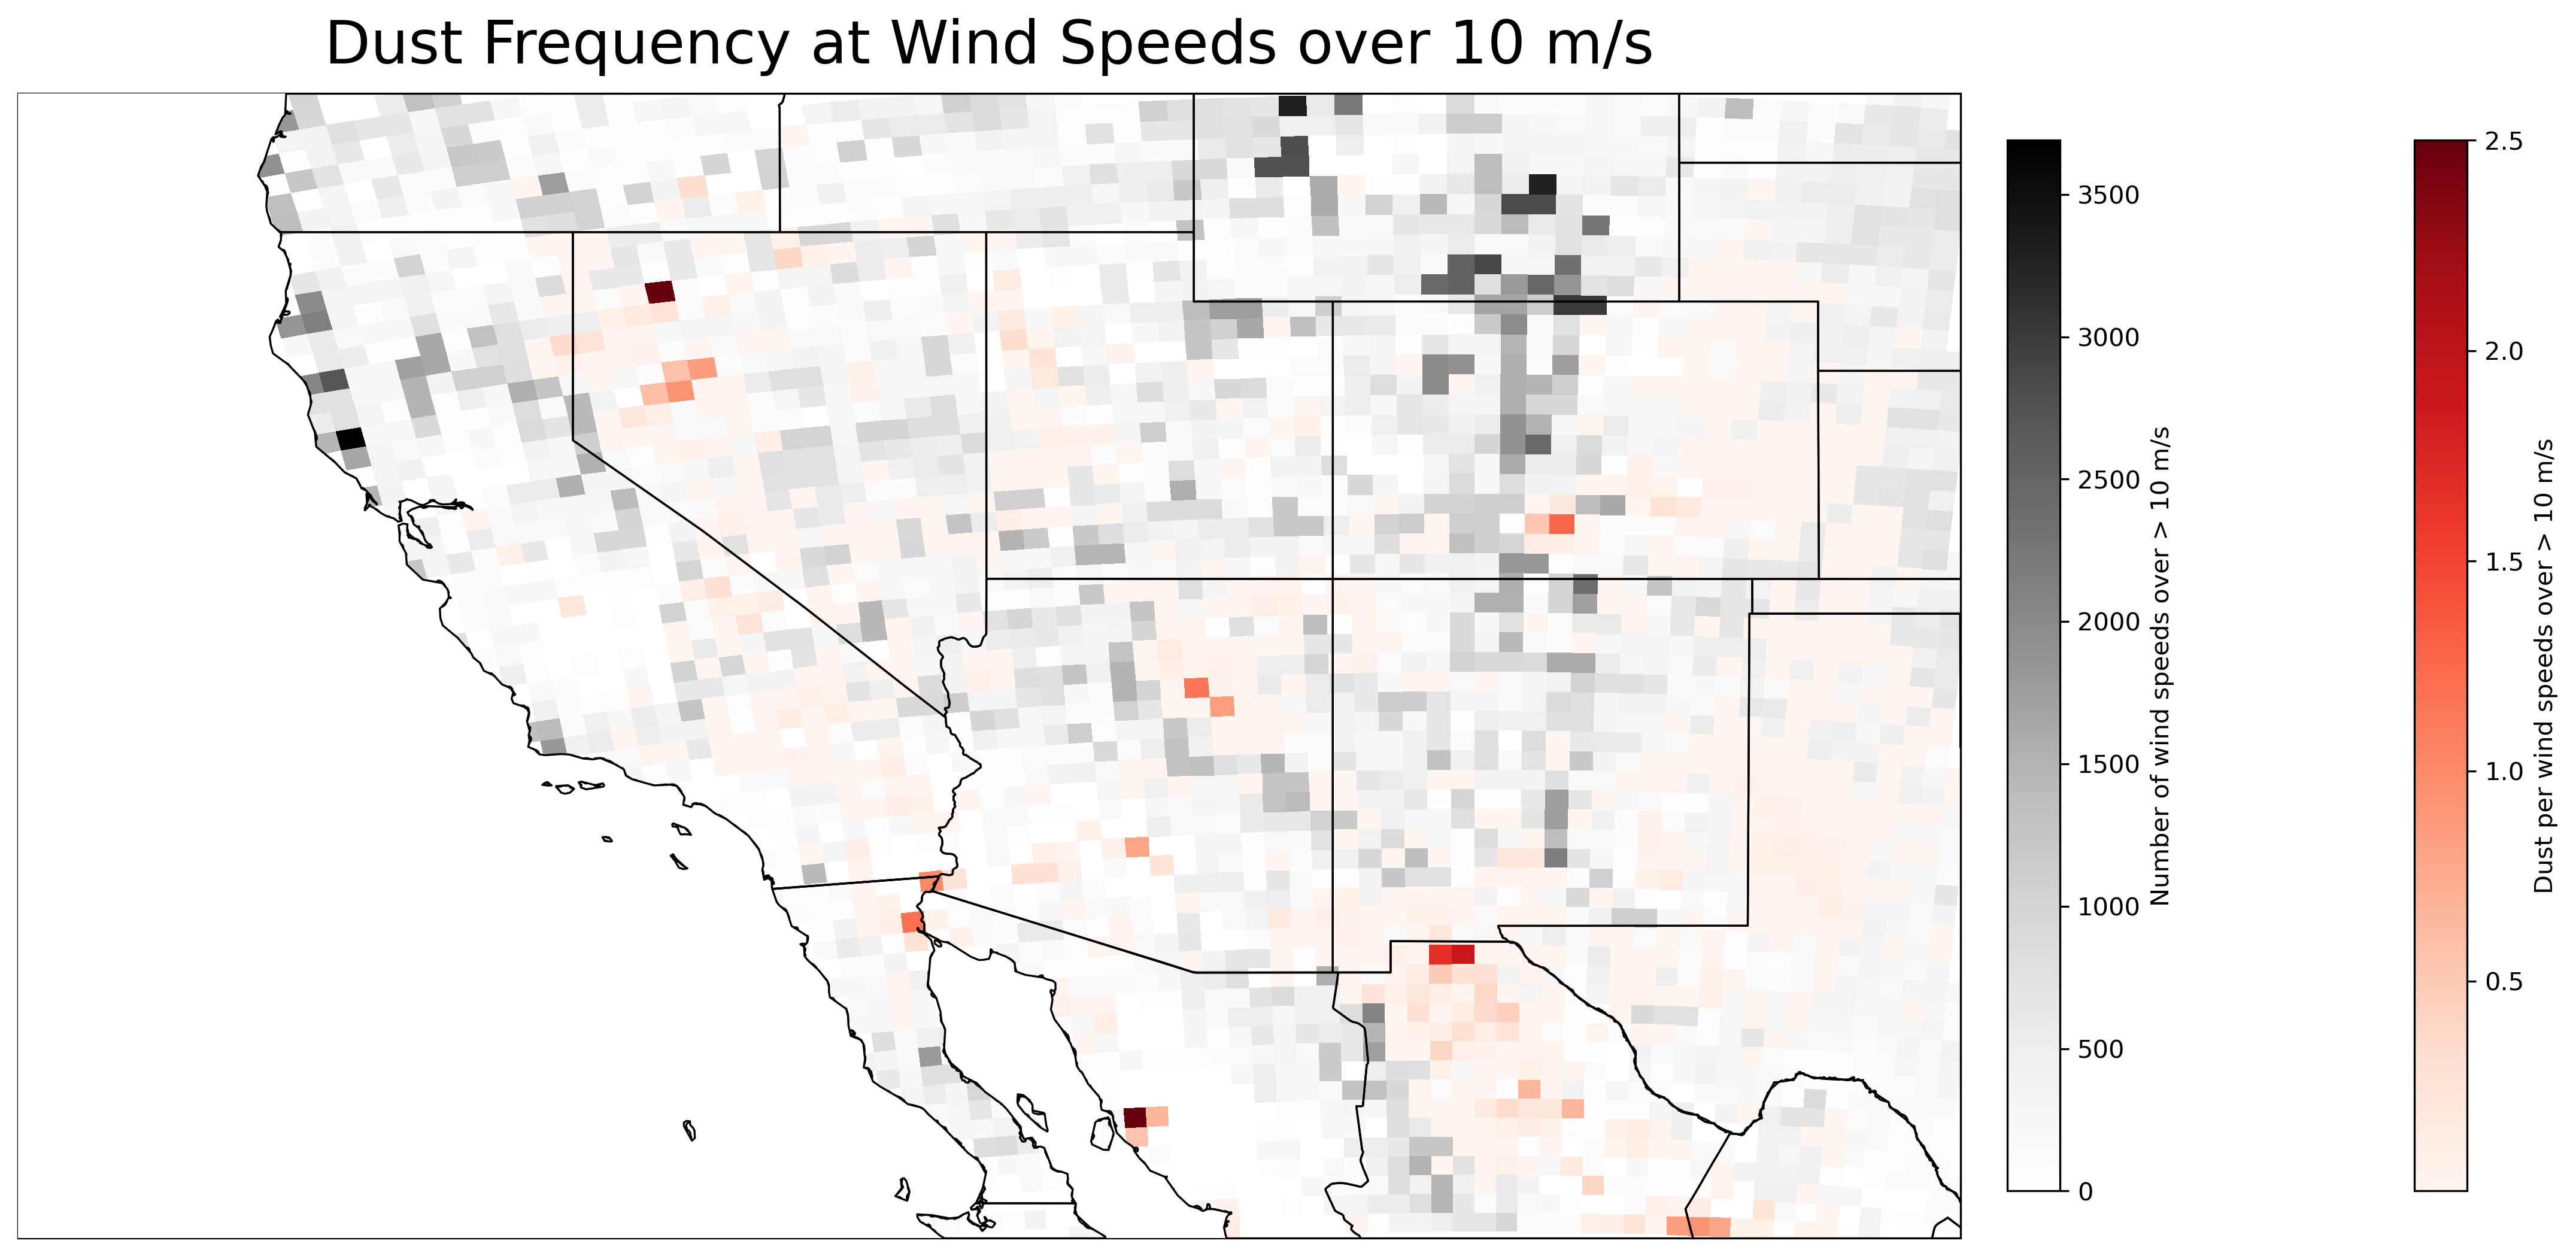

In [39]:
fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={"projection": ccrs.PlateCarree()}, dpi=300)

cf_winds = ax.pcolormesh(
    winds_over_10['lon'], 
    winds_over_10['lat'],
    winds_over_10,
    transform=ccrs.PlateCarree(),
    cmap='Greys')

ratio = counts / winds_over_10
ratio = np.ma.masked_where(counts == 0, ratio)

cf_dust = ax.pcolormesh(
    winds_over_10['lon'], 
    winds_over_10['lat'],
    ratio,
    transform=ccrs.PlateCarree(),
    cmap='Reds')

cbar_dust = plt.colorbar(cf_dust, ax=ax, orientation='vertical', pad=0.02, shrink=0.5)
cbar_dust.set_label('Dust per wind speeds over > 10 m/s')

cbar_winds = plt.colorbar(cf_winds, ax=ax, orientation='vertical', pad=0.02, shrink=0.5)
cbar_winds.set_label('Number of wind speeds over > 10 m/s')

ax.set_title("Dust Frequency at Wind Speeds over 10 m/s", fontsize=24, pad=12)

all_states_provinces = cfeature.NaturalEarthFeature(category='cultural',
    name='admin_1_states_provinces', scale='10m', facecolor='none')
ax.add_feature(all_states_provinces, linewidth=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=3)
min_lat, max_lat, min_lon, max_lon = common_functions._get_coords_for_region(location_name)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

plt.tight_layout()
plt.show()